# Introduction:

In the first part of this series, [`Feature_Engineering`](https://www.kaggle.com/code/sebastianvpal/feature-engineering/edit/run/352689380), the relevance of each feature to the target variable was assessed using feature importance from `RandomForestRegressor` and `XGBRegressor`, `Pearson` and `Spearman` correlation coefficients, and `Mutual Information` (corrected for each series' own autocorrelation via a block-bootstrap null). These metrics were used to categorize the features by the strength and shape of their relationship with the target, and the categorizations were then cross-checked against one another to decide which features to keep, drop, or flag for review. In this second part, the retained features are further engineered: the question is no longer whether a feature carries information relevant to the target, but how to extract the maximum predictive value from each feature's intrinsic information.

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import warnings
from dataclasses import dataclass, asdict
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Data Classes Helpers


In [2]:
@dataclass
class DatasetOutput:
    X_train: pl.DataFrame
    X_test: pl.DataFrame
    y_train: pl.Series
    y_test: pl.Series
    scaler: StandardScaler
    scaled: bool

    def __post_init__(self):
        '''Validates that each field holds the expected type, and that
        train/test splits are internally consistent.'''

        # --- type checks ---
        if not isinstance(self.X_train, pl.DataFrame):
            raise TypeError(
                f"X_train must be pl.DataFrame, got {type(self.X_train)}"
            )
        if not isinstance(self.X_test, pl.DataFrame):
            raise TypeError(
                f"X_test must be pl.DataFrame, got {type(self.X_test)}"
            )
        if not isinstance(self.y_train, pl.Series):
            raise TypeError(
                f"y_train must be pl.Series, got {type(self.y_train)}"
            )
        if not isinstance(self.y_test, pl.Series):
            raise TypeError(
                f"y_test must be pl.Series, got {type(self.y_test)}"
            )
        if not isinstance(self.scaler, StandardScaler):
            raise TypeError(
                f"scaler must be sklearn StandardScaler, got {type(self.scaler)}"
            )

        # --- shape / consistency checks ---
        if self.X_train.height != len(self.y_train):
            raise ValueError(
                f"X_train has {self.X_train.height} rows but y_train has "
                f"{len(self.y_train)} entries"
            )
        if self.X_test.height != len(self.y_test):
            raise ValueError(
                f"X_test has {self.X_test.height} rows but y_test has "
                f"{len(self.y_test)} entries"
            )
        if self.X_train.columns != self.X_test.columns:
            raise ValueError(
                f"X_train and X_test have mismatched columns: "
                f"{self.X_train.columns} vs {self.X_test.columns}"
            )

        # --- emptiness checks ---
        if self.X_train.height == 0:
            raise ValueError("X_train is empty")
        if self.X_test.height == 0:
            raise ValueError("X_test is empty")

        # --- scaler fitted check ---
        # A fitted StandardScaler has learned attributes ending in "_"
        # (mean_, scale_, var_). If they're absent, .fit() was never called.
        if not hasattr(self.scaler, "mean_"):
            warnings.warn(
                "scaler has not been fitted (missing 'mean_' attribute) — "
                "call scaler.fit(X_train) before constructing DatasetOutput"
            )

# Function Helpers

In [3]:
def load_set(target_variable: str, file_name : str, n_exclude : int,
             shift_train_target: bool = False,) -> pl.DataFrame:
    """
    Loads and preprocesses the training dataset.
    Inputs:
    target_variable (str): variable that is the target of the predictions
    file_name (str) : the name of the file to be loaded
    n_exclude (int) : exclude the n last rows
    shift_train_target (bool): if True, shifts the target column up by
            one row, so that features at row t align with the target's
            value at row t+1, matching the feature/target alignment
            convention used in the test set. Defaults to False.
    
    Returns:
        pl.DataFrame: The preprocessed training DataFrame.
    """

    df = (pl.read_csv(DATA_PATH / file_name)
        .rename({target_variable:'target'})
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False) #cast to Float64 all columns except date
        )
        )
    total_exclude = max(n_exclude, 0)
    
    if shift_train_target:
        df = df.with_columns(pl.col("target").shift(-1).alias("target"))
        # the shift leaves the last row's target as null (no t+1 available);
        # fold that into the trailing-row exclusion so it's always dropped
        total_exclude += 1
        
    if total_exclude > 0:
        df = df.head(-total_exclude)
    return (df)


def split_dataset(train: pl.DataFrame, test: pl.DataFrame, features: list[str],
                 standard_scaler_bool: bool) -> DatasetOutput: 
    """
    Splits the data into features (X) and target (y), and scales the features.

    Args:
        train (pl.DataFrame): The processed training DataFrame.
        test (pl.DataFrame): The processed testing DataFrame.
        features (list[str]): List of features to used in model. 
        standard_scaler_bool (bool): Whether or not standard scaler is applied to the data.

    Returns:
        DatasetOutput: A dataclass containing the scaled feature sets, target series, and the fitted scaler.
    """
    # ========== For both, train and test, it drops date_id and target for the X features ===========
    # ========= and takes "target" for the Y (prediction) ===========================================
    X_train = train.drop(['date_id','target']) 
    y_train = train.get_column('target')
    
    X_test = test.drop(['date_id','target']) 
    y_test = test.get_column('target')

    if standard_scaler_bool:
        scaler = StandardScaler() 
        
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_train = pl.from_numpy(X_train_scaled_np, schema=features)
        
        X_test_scaled_np = scaler.transform(X_test)
        X_test = pl.from_numpy(X_test_scaled_np, schema=features)
    else:
        scaler = StandardScaler() 
    
    
    return DatasetOutput(
        X_train = X_train,
        y_train = y_train, 
        X_test = X_test, 
        y_test = y_test,
        scaler = scaler,
        scaled = standard_scaler_bool,
    )

# Reading DataFrames

In [4]:
DATA_PATH = Path("/kaggle/input/notebooks/sebastianvpal/feature-engineering")
file_train = "ds_train_no_noise.csv"
file_test = "ds_test_no_noise.csv"
# =========== Reading files ===============0
target_variable_training = 'market_forward_excess_returns'
target_variable_test_val = 'lagged_forward_returns'
#===========
ds_train = load_set(target_variable=target_variable_training, 
                    file_name = file_train, n_exclude = 10, shift_train_target=True)
                        # align features(t) -> target(t+1), matching test set) 
#===========
ds_test = load_set(target_variable=target_variable_test_val, 
                    file_name = file_test, n_exclude=0) 

In [5]:
features_to_drop_train = ["forward_returns", "risk_free_rate"]
features_to_drop_test_val = ["lagged_risk_free_rate", "lagged_market_forward_excess_returns"]

ds_train = ds_train.drop(features_to_drop_train)
ds_test = ds_test.drop(features_to_drop_test_val)

In [6]:
exclude_from_features = ['forward_returns','risk_free_rate','target']
FEATURES = [col for col in ds_train.columns if col not in exclude_from_features]


# K-means in feature space

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import kruskal

In [8]:
def select_n_clusters( df_train: pl.DataFrame, features: list[str],
                     k_range: range(2,11), seed: int = 42) -> pl.DataFrame:
    """Scans a range of candidate cluster counts (k) and scores each with the silhouette
    coefficient (it measured how similar is a point to its own cluster compared with
    other clusters; 1: optimal well separated clusters,
    0: on the decision boundary between clusters,
    -1: sample assigned to the wrong cluster), 
    to pick a defensible k before committing to a regime-detection pipeline
    instead of guessing a value.

    Mechanics: for each k, fits KMeans on the TRAINING features only (standardized first,
    since k-means uses Euclidean distance and is scale-sensitive — an unscaled feature
    with a larger numeric range would dominate the distance metric purely from units, not
    genuine separation). The silhouette score measures, for every point, how much closer
    it sits to its own cluster's center versus the nearest other cluster's center,
    averaged over all points; it ranges from -1 (badly clustered) to +1 (cleanly separated).

    Args:
        df_train: training-fold data only — selecting k on data that includes validation/
            test rows would let future information leak into a modeling choice.
        features: feature columns to cluster on (should already be your cleaned,
            NaN-free).
        k_range: candidate values of k to try.
        seed: random_state for KMeans reproducibility (k-means' result depends on its
            random centroid initialization).

    Returns:
        pl.DataFrame with columns 'k' and 'silhouette_score', one row per candidate k.
        Pick the k at (or near) the peak score — not necessarily the global max if a
        smaller, nearly-as-good k gives a simpler, more interpretable result.
    """
    # == StandardScaler
    X = StandardScaler().fit_transform(df_train.select(features).to_numpy())
    rows = []
    for k in k_range:
        labels = KMeans(n_clusters=k, random_state=seed, n_init=10).fit_predict(X)
        score = silhouette_score(X, labels)
        rows.append({"k":k, "silhouette_score":score})
    return pl.DataFrame(rows)

def fit_cluster_model( df_train: pl.DataFrame, features: list[str], n_clusters: int,
                     seed: int = 42) -> tuple[StandardScaler, KMeans]:
    """Fits the scaler and the k-means model on TRAINING data only. Both fitted objects
    are returned so the exact same transformation (same centering/scaling, same cluster
    centroids) can later be applied to validation/test/future rows via assign_clusters()
    — fitting a fresh scaler or k-means on new data would silently leak that data's own
    distribution into the clustering, the same look-ahead problem already flagged for
    PCA and StandardScaler earlier in this pipeline.

    Args:
        df_train: training-fold rows only.
        features: feature columns to cluster on.
        n_clusters: number of clusters (k), typically chosen via select_n_clusters().
        seed: random_state for reproducibility.

    Returns:
        (scaler, kmeans): fitted StandardScaler and fitted KMeans model. Persist both
        together (e.g. pickle as a pair) — a kmeans model is meaningless without the
        exact scaler that produced the space it was fit in.
    """
    scaler = StandardScaler()
    X_train = scaler.fit_transform(df_train.select(features).to_numpy())
    kmeans = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    kmeans.fit(X_train)
    return scaler, kmeans

def assign_clusters( df: pl.DataFrame, features: list[str], scaler: StandardScaler,
                    kmeans: KMeans) -> pl.DataFrame:
    """Applies an ALREADY-FITTED scaler and k-means model to assign cluster labels and
    centroid distances to any dataframe (train, validation, test, or future live data).
    Never re-fits anything here — assignment only requires the feature columns (X),
    never the target, so this is safe to call on genuinely unseen future rows without
    any leakage.

    Args:
        df: any dataframe containing the same feature columns used to fit the model.
        features: same feature list/order used in fit_cluster_model.
        scaler: the StandardScaler returned by fit_cluster_model.
        kmeans: the KMeans model returned by fit_cluster_model.

    Returns:
        df with two new column groups added:
        - 'cluster_label': the assigned cluster id (0..n_clusters-1) for each row.
        - 'dist_to_cluster_{i}' for each cluster i: Euclidean distance (in the scaled
          feature space) from the row to that cluster's centroid. Keeping ALL distances
          (not just the assigned one) gives downstream models a continuous notion of
          "how typical/atypical" a row is for every regime, not just a hard label.
    """
    X = scaler.transform(df.select(features).to_numpy())
    labels = kmeans.predict(X)
    distances = kmeans.transform(X) #shape: (n_rows, n_clusters)

    out = df.with_columns(pl.Series("cluster_label",labels))
    for i in range(distances.shape[1]): #moving trhough each cluster
        out = out.with_columns(pl.Series(f"dist_to_cluster_{i}",distances[:,i]))
    return out

def profile_clusters_against_target(df_with_clusters: pl.DataFrame, target: str) -> pl.DataFrame:
    """Checks whether the unsupervised feature-space clusters correspond to meaningfully
    different target behavior — the diagnostic step that decides whether clustering is
    worth keeping as a feature at all, rather than just assuming it helps.

    For each cluster, reports basic target statistics, then runs a Kruskal-Wallis test
    (a nonparametric one-way ANOVA — doesn't assume normality, appropriate for a return-
    like target) across all clusters' target distributions, to get a single p-value for
    "do these clusters differ in target behavior more than chance would produce?"

    Args:
        df_with_clusters: output of assign_clusters(), must contain 'cluster_label'
            and the target column.
        target: name of the target column.

    Returns:
        pl.DataFrame with one row per cluster: 'cluster_label', 'n_obs', 'target_mean',
        'target_std', 'target_p10', 'target_p90'. Also prints the Kruskal-Wallis
        statistic and p-value for the full set of clusters — a small p-value (e.g. <0.05)
        is evidence the clusters capture real, distinguishable regimes; a large p-value
        means the clustering, however clean it looks in feature space (per silhouette
        score), doesn't correspond to different target behavior and isn't worth keeping
        as a feature.
    """
    summary = (
        df_with_clusters.group_by("cluster_label")
        .agg(
            pl.len().alias("n_obs"), #number of observations 
            pl.col(target).mean().alias("target_mean"), #mean target value for each cluster
            pl.col(target).std().alias("target_std"),
            pl.col(target).quantile(0.10).alias("target_p10"),
            pl.col(target).quantile(0.90).alias("target_p90"),
        )
        .sort("cluster_label")
    )
    groups = [
        df_with_clusters.filter(pl.col("cluster_label")==c)[target].to_numpy()
        for c in summary["cluster_label"].to_list()
    ]
    stat, p_value = kruskal(*groups)
    print(f"Kruksal_Wallis H={stat:.3f}, p={p_value:.4g}")
    if p_value < 0.05:
        print("Clusters show significantly different target behavior — worth keeping as a feature.")
    else:
        print("No significant target difference across clusters — clustering likely not useful here.")

    return summary

from scipy.stats import levene, fligner

def profile_cluster_dispersion(df_with_clusters: pl.DataFrame, target: str) -> None:
    """Tests whether target VARIANCE (not just median) differs across clusters —
    Kruskal-Wallis only tests location, so a volatility-regime effect (plausible given
    this target's near-zero mean/autocorrelation) would be invisible to it but should
    show up here.
    """
    groups = [
        df_with_clusters.filter(pl.col("cluster_label") == c)[target].to_numpy()
        for c in df_with_clusters["cluster_label"].unique().sort().to_list()
    ]
    # Levene's test: standard variance-equality test, somewhat sensitive to non-normality
    lev_stat, lev_p = levene(*groups)
    # Fligner-Killeen: nonparametric alternative to Levene, more robust to heavy tails
    # (safer choice for financial returns, which are rarely close to normal)
    fk_stat, fk_p = fligner(*groups)

    print(f"Levene's test:         stat={lev_stat:.3f}, p={lev_p:.4g}")
    print(f"Fligner-Killeen test:  stat={fk_stat:.3f}, p={fk_p:.4g}")
    if fk_p < 0.05:
        print("Clusters show significantly different target VARIANCE — volatility-regime effect.")



Usage order: `select_n_clusters(train)` → pick k → `fit_cluster_model(train, k)` → `assign_clusters(train/val/test, ...)` → `profile_clusters_against_target(train_with_clusters, target)` to decide whether to actually keep cluster_label/dist_to_cluster_* as model features.

**Note:** Because my features have different temporal coverage, some of them has NaN values. StandardScaler and KMeans require the features to have finite values, for this reason I can think of 2 alternatives:

1. Crop all features to the same temporal coverage dropping time information: Applying this approach drops 84% of the data and gives as result

`Kruksal_Wallis H=2.852, p=0.9433
No significant target difference across clusters — clustering likely not useful here.`

2. drop features with the lower temporal coverage this will keep time information but neglecting completly some features

## Implementation of first approach

In [9]:
ds_train_noNulls = ds_train.drop_nulls()
len_nulls = ds_train.height
len_NoNulls = ds_train_noNulls.height

print(f"Ratio of noNulls/Nulls samples: {len_NoNulls/len_nulls}")

Ratio of noNulls/Nulls samples: 0.16172394678492238


## Implementation of second approach

In [10]:
import polars as pl

def compute_feature_coverage(df: pl.DataFrame, features: list[str]) -> pl.DataFrame:
    """Builds a per-feature coverage table: how many valid (non-null) rows each feature
    has, and whether its missingness is a clean leading gap (warm-up) or scattered
    throughout the series — the latter won't be fixed just by cropping to a later
    start date.

    Args:
        df: full dataset (with a row-order/date column implicitly given by row position).
        features: feature columns to assess.

    Returns:
        pl.DataFrame with 'feature', 'n_valid', 'coverage_ratio' (n_valid / n_total),
        'first_valid_idx', 'last_valid_idx', 'is_leading_gap_only' (True if every null
        occurs before first_valid_idx, i.e. simple warm-up; False if nulls are scattered
        after the feature's first valid value too).
    """
    n_total = df.height
    rows = []
    for feat in features:
        s = df[feat]
        valid_mask = s.is_not_null()
        n_valid = valid_mask.sum()
        valid_idx = [i for i, v in enumerate(valid_mask) if v]
        first_valid = valid_idx[0] if valid_idx else None
        last_valid = valid_idx[-1] if valid_idx else None
        # if coverage were a pure leading gap, n_valid should equal (n_total - first_valid)
        is_leading_gap_only = (
            first_valid is not None and n_valid == (n_total - first_valid)
        )
        rows.append({
            "feature": feat, "n_valid": n_valid, "coverage_ratio": n_valid / n_total,
            "first_valid_idx": first_valid, "last_valid_idx": last_valid,
            "is_leading_gap_only": is_leading_gap_only,
        })
    return pl.DataFrame(rows).sort("n_valid", descending=True)


def select_features_by_coverage(coverage_df: pl.DataFrame, min_ratio_of_max: float = 0.75) -> list[str]:
    """Selects features whose coverage is at least `min_ratio_of_max` of the single
    best-covered feature's coverage (your 'max' reference), as a pre-filter before
    taking the row-wise intersection for clustering.

    Args:
        coverage_df: output of compute_feature_coverage().
        min_ratio_of_max: cutoff relative to the max-covered feature's n_valid.

    Returns:
        list of feature names clearing the threshold.
    """
    max_n_valid = coverage_df["n_valid"].max()
    kept = coverage_df.filter(pl.col("n_valid") >= min_ratio_of_max * max_n_valid)
    print(f"Kept {kept.height}/{coverage_df.height} features at ratio >= {min_ratio_of_max}")
    return kept["feature"].to_list()


# --- apply ---
coverage = compute_feature_coverage(ds_train, FEATURES)
print(coverage)  # inspect the distribution and is_leading_gap_only before picking a threshold

cluster_features = select_features_by_coverage(coverage, min_ratio_of_max=0.86)
ds_train_cropped = ds_train.select(cluster_features + ["target"]).drop_nulls()

ratio_before = ds_train.drop_nulls().height / ds_train.height
ratio_after = ds_train_cropped.height / ds_train.height
print(f"Row retention before: {ratio_before:.3f} -> after coverage filtering: {ratio_after:.3f}")

shape: (73, 6)
┌─────────┬─────────┬────────────────┬─────────────────┬────────────────┬─────────────────────┐
│ feature ┆ n_valid ┆ coverage_ratio ┆ first_valid_idx ┆ last_valid_idx ┆ is_leading_gap_only │
│ ---     ┆ ---     ┆ ---            ┆ ---             ┆ ---            ┆ ---                 │
│ str     ┆ i64     ┆ f64            ┆ i64             ┆ i64            ┆ bool                │
╞═════════╪═════════╪════════════════╪═════════════════╪════════════════╪═════════════════════╡
│ date_id ┆ 7216    ┆ 1.0            ┆ 0               ┆ 7215           ┆ true                │
│ D1      ┆ 7216    ┆ 1.0            ┆ 0               ┆ 7215           ┆ true                │
│ D2      ┆ 7216    ┆ 1.0            ┆ 0               ┆ 7215           ┆ true                │
│ E10     ┆ 6210    ┆ 0.860588       ┆ 1006            ┆ 7215           ┆ true                │
│ E11     ┆ 6210    ┆ 0.860588       ┆ 1006            ┆ 7215           ┆ true                │
│ …       ┆ …       ┆ …  

## Applying pipeline

In [11]:
FEATURES_DROP = [col for col in ds_train_cropped.columns if col not in exclude_from_features]

In [12]:
# ========= Checks among the K cluster candidates the best one using the silhouette_score ===
K_candidates = select_n_clusters( df_train= ds_train_cropped, features=FEATURES_DROP,
                     k_range= range(2,15), seed= 42)
print(K_candidates)
best_K = K_candidates.sort("silhouette_score",descending=True)[0]["k"].item()
print(f"Best K is: {best_K}")

shape: (13, 2)
┌─────┬──────────────────┐
│ k   ┆ silhouette_score │
│ --- ┆ ---              │
│ i64 ┆ f64              │
╞═════╪══════════════════╡
│ 2   ┆ 0.148436         │
│ 3   ┆ 0.159377         │
│ 4   ┆ 0.196193         │
│ 5   ┆ 0.222045         │
│ 6   ┆ 0.201973         │
│ …   ┆ …                │
│ 10  ┆ 0.240358         │
│ 11  ┆ 0.237276         │
│ 12  ┆ 0.243625         │
│ 13  ┆ 0.246017         │
│ 14  ┆ 0.242329         │
└─────┴──────────────────┘
Best K is: 13


In [13]:
# ==== This gives me a touple as: (StandardScaler(), KMeans(n_clusters=9, n_init=10, random_state=42)) ==
ds_train_KMeans = fit_cluster_model( df_train=ds_train_cropped, features=FEATURES_DROP, 
                                    n_clusters=best_K,seed = 42)


In [14]:
ds_train_KMeans_out = assign_clusters( df=ds_train_cropped, features=FEATURES_DROP, scaler=ds_train_KMeans[0],
                    kmeans=ds_train_KMeans[1])

In [15]:
ds_train_KMeans_out

date_id,D1,D2,E10,E11,E12,E14,E15,E16,E17,E18,E19,E2,E3,E5,E8,E9,I2,I3,I4,I5,I7,I9,M10,M11,M12,M16,M17,M18,M4,M7,M8,M9,P10,P11,P12,P2,P8,P9,S1,S10,S11,S2,S6,S7,V1,V11,V12,V2,V3,V4,V8,target,cluster_label,dist_to_cluster_0,dist_to_cluster_1,dist_to_cluster_2,dist_to_cluster_3,dist_to_cluster_4,dist_to_cluster_5,dist_to_cluster_6,dist_to_cluster_7,dist_to_cluster_8,dist_to_cluster_9,dist_to_cluster_10,dist_to_cluster_11,dist_to_cluster_12
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1006,0.0,0.0,0.597222,0.035053,0.018519,0.005952,0.520172,1.116487,0.6802938,-0.199948,-0.882935,2.021695,1.794863,0.864087,-0.66887,0.003307,-1.921693,0.597222,0.540344,-1.320764,0.793651,-1.319295,0.546719,-1.127094,-1.44174,0.000661,0.018849,0.495701,0.3081965,1.193217,0.000661,1.147322,1.757342,1.787456,0.539249,-1.576455,1.763894,0.652778,-1.059103,0.000661,0.000661,1.208733,0.417989,0.607143,0.000661,0.000661,0.000661,0.986772,0.970899,0.986111,0.000661,0.001565,7,7.515246,8.333808,10.283057,5.835001,9.270155,8.900113,8.239996,4.728023,8.666478,7.734495,13.567794,8.615254,9.338256
1007,0.0,0.0,0.597884,0.034722,0.018188,0.005622,0.520503,1.116244,0.6815046,-0.198796,-1.113241,2.020056,1.793937,0.864418,-0.723671,0.002976,-1.977569,0.597884,0.565476,-1.31907,0.779431,-1.318068,0.933832,-1.129075,-1.381259,0.000661,0.018519,0.49537,0.3224437,0.670495,0.000661,1.146462,1.75665,1.794681,-0.295458,-1.721848,1.760748,0.653439,-1.064294,0.000661,0.000661,1.207146,0.470569,0.607474,0.000661,0.000661,0.000661,0.984788,0.972884,0.984788,0.000661,-0.001758,7,7.50676,8.280686,10.226778,5.823229,9.242084,9.032783,8.221838,4.57679,8.604956,7.730587,13.524381,8.74428,9.246032
1008,0.0,0.0,0.598545,0.034392,0.017857,0.005291,0.520833,1.116002,0.6827182,-0.197643,-1.113912,2.088565,1.901311,0.864749,-0.723964,0.002646,-2.003693,0.598545,0.568783,-1.31237,0.824735,-1.311568,0.93263,-1.134355,-1.423275,0.000661,0.018188,0.49504,0.5972948,0.670086,0.000661,1.1778,1.771404,1.831524,0.331242,-1.589883,1.764136,0.654101,-1.063939,0.000661,0.000661,1.088541,0.541667,0.607804,0.000661,0.000661,0.000661,0.982143,0.834656,0.983466,0.000661,-0.004415,7,7.45776,8.281665,10.167412,5.702146,9.223636,9.019762,8.164913,4.525266,8.509198,7.682593,13.600048,8.635021,9.173944
1009,0.0,0.0,0.599206,0.034061,0.017526,0.00496,0.520503,1.115759,0.6839344,-0.196487,-1.123683,2.094246,1.9116,0.865079,-0.724256,0.002315,-1.990399,0.599206,0.546296,-1.310706,0.799934,-1.319018,0.931429,-1.125089,-1.494785,0.000661,0.017857,0.494709,0.6458612,0.669677,0.000661,1.18042,1.772872,1.842128,-0.712114,-1.601599,1.761746,0.654762,-1.063491,0.000661,0.000661,0.618246,0.62004,0.608135,0.000661,0.000661,0.000661,0.980159,0.928571,0.979497,0.000661,-0.005766,7,7.475631,8.267628,10.188132,5.731901,9.28752,9.076144,8.240158,4.529966,8.557818,7.768341,13.541944,8.792537,9.149393
1010,0.0,0.0,0.599868,0.03373,0.017196,0.00463,0.520172,1.115517,0.6851533,-0.195329,-1.013534,2.082656,1.895303,0.86541,-0.72457,0.001984,-1.967328,0.599868,0.545635,-1.339,0.850198,-1.34228,0.93023,-1.136218,-1.495462,0.000661,0.02877,0.475529,0.360672,0.669269,0.000661,1.175159,1.767071,1.851817,-0.293874,-1.594769,1.758974,0.655423,-1.068476,0.000661,0.000661,0.618119,0.62037,0.608466,0.000661,0.000661,0.000661,1.0,0.997354,1.0,0.000661,-0.003112,7,7.466073,8.347219,10.243527,5.800804,9.302963,9.024688,8.204385,4.502835,8.611373,7.733362,13.560519,8.834233,9.206686
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
7211,0.0,0.0,0.356481,0.00463,0.00463,0.00463,0.005291,0.657428,1.215797,1.530221,-0.456358,1.952679,1.488835,0.828704,-1.589977,0.042328,-0.017036,0.877646,0.382937,2.879229,0.070767,2.877487,2.049684,-0.722887,

In [16]:
summary_KMeans = profile_clusters_against_target(df_with_clusters=ds_train_KMeans_out,
                                                 target='target')

Kruksal_Wallis H=13.179, p=0.3562
No significant target difference across clusters — clustering likely not useful here.


In [17]:
profile_cluster_dispersion(ds_train_KMeans_out, 'target')

Levene's test:         stat=88.237, p=8.638e-202
Fligner-Killeen test:  stat=842.344, p=1.366e-172
Clusters show significantly different target VARIANCE — volatility-regime effect.


## Conclusion:
By using KMeans we created clusters for the features. These new clusters showed no significance for the `Kruksal-Walls`test because this test focuses on the mean variable, i.e. is the mean variable of the target associated to one cluster significantly different to the mean variable of the target associated to another cluster? But as we have seen through the study of these variables, they tend to have a similar mean, and their real difference lies on the outliers, or in this context, the volatility.
For that reason the `Levene`and `Fligner-Killeen`tests are applied. They answer another kind of question, is the `variance` of the feature associated to one cluster significantly different to the variance of the target associated to another cluster? For this case the answer is `YES`. This is showing us that the clusters apport information to our problem, they are separating diferrent variance regimes

## Some Plots

2D projection explains 33.2% of variance — a low number here means this view is a rough sketch, not the full picture


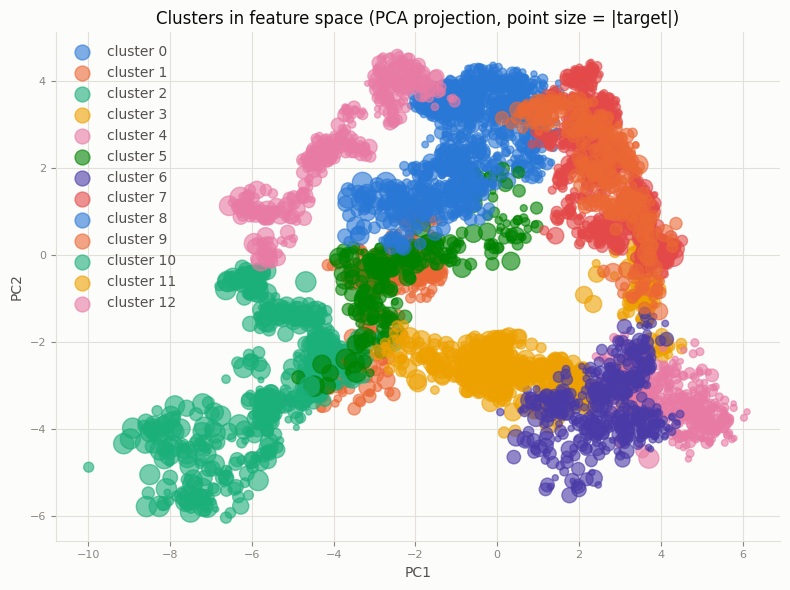

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import scipy.stats as stats

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"
CAT_SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]

X_scaled = ds_train_KMeans[0].transform(ds_train_cropped.select(FEATURES_DROP).to_numpy())  # same fitted scaler
pca_viz = PCA(n_components=2, random_state=42).fit(X_scaled)
coords = pca_viz.transform(X_scaled)
print(f"2D projection explains {pca_viz.explained_variance_ratio_.sum():.1%} of variance — "
      f"a low number here means this view is a rough sketch, not the full picture")



labels = ds_train_KMeans[1].predict(X_scaled)
target_vals = ds_train_cropped["target"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
for c in sorted(set(labels)):
    mask = labels == c
    # =============================
    target_abs = np.abs(target_vals[mask])
    # rank-based: evenly spreads sizes 15-215 regardless of the target's actual distribution shape
    size_rank = 15 + 200 * stats.rankdata(target_abs) / len(target_abs)
    
    # log-based alternative (if you want to keep it value-proportional rather than rank-based):
    size_log = 15 + 200 * np.log1p(target_abs) / np.log1p(target_abs).max()
    
    Size_linear = 15 + 200 * np.abs(target_vals[mask]) / np.abs(target_vals).max()
    #==============================================
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=size_log,  # size = |target|
               color=CAT_SLOTS[c % len(CAT_SLOTS)], alpha=0.6, label=f"cluster {c}", zorder=3)
ax.set_title("Clusters in feature space (PCA projection, point size = |target|)", color=INK_PRIMARY)
ax.set_xlabel("PC1", color=INK_SECONDARY); ax.set_ylabel("PC2", color=INK_SECONDARY)
ax.tick_params(colors=INK_MUTED, labelsize=8)
ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
for s in ["top", "right"]: ax.spines[s].set_visible(False)
for s in ["left", "bottom"]: ax.spines[s].set_color(GRID)
ax.legend(frameon=False, labelcolor=INK_SECONDARY, loc="best")
plt.tight_layout(); plt.show()

***Centroid heatmap — shows which features define each cluster. This answers "which feature does each cluster come from"***

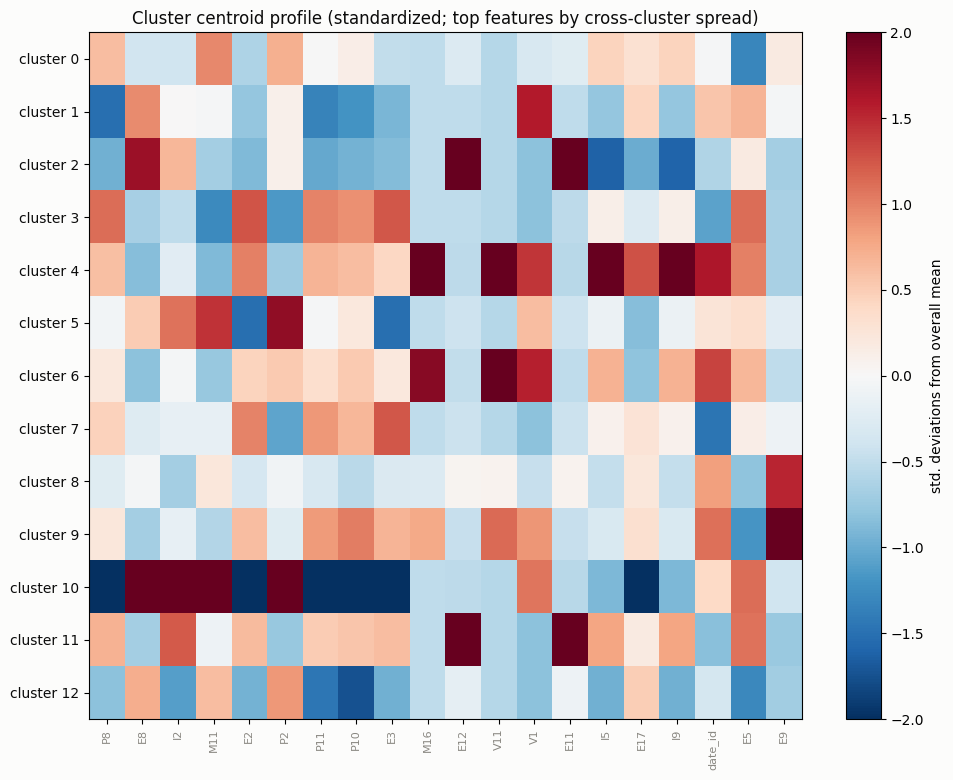

In [19]:
centroids = ds_train_KMeans[1].cluster_centers_  # shape (n_clusters, n_features), already in standardized space

# limit to the most differentiating features for legibility — ranking by variance ACROSS
# cluster centroids picks out the features that actually distinguish clusters, rather
# than cluttering the heatmap with features that look the same in every cluster
top_n = 20
feature_spread = centroids.std(axis=0)
top_idx = np.argsort(feature_spread)[::-1][:top_n]
top_features = [FEATURES_DROP[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 4 + 0.3 * len(set(labels))))
fig.patch.set_facecolor(SURFACE)
# == plots the centroid of each feature (2D space: cluster, feature)
im = ax.imshow(centroids[:, top_idx], cmap="RdBu_r", aspect="auto", vmin=-2, vmax=2) 
# diverging: 0 = "typical"
ax.set_xticks(range(len(top_features))); ax.set_xticklabels(top_features, rotation=90, fontsize=8, color=INK_MUTED)
ax.set_yticks(range(centroids.shape[0])); ax.set_yticklabels([f"cluster {i}" for i in range(centroids.shape[0])], color=INK_PRIMARY)
ax.set_title("Cluster centroid profile (standardized; top features by cross-cluster spread)", color=INK_PRIMARY)
cbar = fig.colorbar(im, ax=ax, label="std. deviations from overall mean")
plt.tight_layout(); plt.show()

## Attaching dropped features:
For KMeans, the features that were not present for the time window we defined were dropped, this is because KMeans and StandardScaler cannot deal with `Null`data. Therefore, in the previous step, we dropped these features and then for the remaining features, we dropped any row that had null. By doing this, one assured that the remaining features met the threshold value of the amount of data. Now, these dropped features will be attached to the training dataset so there is no loss information. 

### Checking which features were dropped

In [20]:
features_ds_KMeans = ds_train_cropped.columns
features_ds_input = ds_train.columns

print(f"Removed columns for KMeans: {set(features_ds_input)-set(features_ds_KMeans)}")
print(f"Original size of the dataset: {ds_train.shape}, size for KMeans:" \
      f"{ds_train_cropped.shape}")

Removed columns for KMeans: {'M13', 'M1', 'V13', 'S5', 'E20', 'S12', 'M5', 'M2', 'M3', 'V9', 'S8', 'V5', 'V10', 'V7', 'M6', 'E1', 'M14', 'P5', 'P7', 'S3', 'P6'}
Original size of the dataset: (7216, 74), size for KMeans:(6210, 53)


In [21]:
ds_train_final = ds_train.join(
    ds_train_KMeans_out.select(["date_id","cluster_label"] + [c for c in ds_train_KMeans_out.columns if c.startswith("dist_to_cluster_")]),
                              on="date_id",
                              how="left",)

In [22]:
print(f"Columns present in final that were not in initial ds trianing"\
f"{set(ds_train_final.columns)-set(features_ds_input)}")
print(f"Final size of ds training: {ds_train_final.shape}")

Columns present in final that were not in initial ds trianing{'dist_to_cluster_1', 'dist_to_cluster_2', 'dist_to_cluster_8', 'dist_to_cluster_4', 'dist_to_cluster_9', 'dist_to_cluster_10', 'dist_to_cluster_5', 'dist_to_cluster_3', 'dist_to_cluster_0', 'dist_to_cluster_6', 'cluster_label', 'dist_to_cluster_7', 'dist_to_cluster_12', 'dist_to_cluster_11'}
Final size of ds training: (7216, 88)


### Applying the same clustering to the test set
The same clusters are applied to the test set, no transform on the test set is done, but it uses the already information learned from the train for both `StandardScaler`and `KMeans`

In [23]:
# clean the TEST set the same way as training: must still drop rows with nulls 

ds_test_cropped = ds_test.select(FEATURES_DROP + ["target"]).drop_nulls()

ds_test_KMeans_out = assign_clusters(
    df=ds_test_cropped,
    features=FEATURES_DROP,
    scaler=ds_train_KMeans[0],   # frozen, fitted on train only — correct, keep as-is
    kmeans=ds_train_KMeans[1],   # frozen, fitted on train only — correct, keep as-is
)

In [24]:
features_ds_KMeans_test = ds_test_cropped.columns
features_ds_input_test = ds_test.columns

print(f"Removed columns for KMeans: {set(features_ds_input_test)-set(features_ds_KMeans_test)}")
print(f"Original size of the dataset: {ds_test.shape}, size for KMeans:" \
      f"{ds_test_cropped.shape}")

Removed columns for KMeans: {'M13', 'M1', 'V13', 'S5', 'E20', 'S12', 'M5', 'M2', 'M3', 'V9', 'S8', 'V5', 'V10', 'V7', 'M6', 'E1', 'M14', 'P5', 'P7', 'S3', 'P6'}
Original size of the dataset: (905, 74), size for KMeans:(905, 53)


In [25]:
ds_test_final = ds_test.join(
    ds_test_KMeans_out.select(["date_id","cluster_label"] + [c for c in ds_test_KMeans_out.columns if c.startswith("dist_to_cluster_")]),
                              on="date_id",
                              how="left",)

In [26]:
print(f"Columns present in final that were not in initial ds trianing"\
f"{set(ds_test_final.columns)-set(features_ds_input_test)}")
print(f"Final size of ds training: {ds_test_final.shape}")


Columns present in final that were not in initial ds trianing{'dist_to_cluster_1', 'dist_to_cluster_2', 'dist_to_cluster_8', 'dist_to_cluster_4', 'dist_to_cluster_9', 'dist_to_cluster_10', 'dist_to_cluster_5', 'dist_to_cluster_3', 'dist_to_cluster_0', 'dist_to_cluster_6', 'cluster_label', 'dist_to_cluster_7', 'dist_to_cluster_12', 'dist_to_cluster_11'}
Final size of ds training: (905, 88)


### Check that both train and test have the same features

In [27]:
KMEAN_FEATURES_TRAIN = set(ds_train_final.columns)
KMEAN_FEATURES_TEST = set(ds_test_final.columns)

only_in_train = KMEAN_FEATURES_TRAIN - KMEAN_FEATURES_TEST
only_in_test = KMEAN_FEATURES_TEST - KMEAN_FEATURES_TRAIN

if only_in_train:
    print(f"Only in train ({len(only_in_train)}): {sorted(only_in_train)}")
if only_in_test:
    print(f"Only in test ({len(only_in_test)}): {sorted(only_in_test)}")
if not only_in_train and not only_in_test:
    print("Train and test have identical feature sets.")

Train and test have identical feature sets.


# Implementing HistGradBoostRegressor:
Now, the `HistGradBoostRegressor`will be trained on the new data and compare with our benchmarks

In [28]:
from scipy.stats import randint, uniform
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

In [29]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train_final.columns if col not in ['date_id', 
                                                                      'forward_returns','risk_free_rate',
                                                                      'target']]

# creating the dataset. This data will be used for RandomForest, so standardscaler is NOT needed
dataset: DatasetOutput = split_dataset(train=ds_train_final, test=ds_test_final, features=FEATURES,
                                      standard_scaler_bool= False) 

X_train: pl.DataFrame = dataset.X_train
X_test: pl.DataFrame = dataset.X_test
y_train: pl.DataFrame = dataset.y_train
y_test: pl.DataFrame = dataset.y_test
scaler: StandardScaler = dataset.scaler 
scaled: bool = dataset.scaled

/tmp/ipykernel_58/1883765255.py:63: UserWarning: scaler has not been fitted (missing 'mean_' attribute) — call scaler.fit(X_train) before constructing DatasetOutput
  warnings.warn(


In [30]:
@dataclass
class HGBCV_params:
    max_depth: object          # distribution or array of candidate max_depth values
    min_samples_leaf: object   # distribution or array of candidate min_samples_leaf values
    max_leaf_nodes: object     # distribution or array of candidate max_leaf_nodes values
    learning_rate: object      # distribution or array of candidate learning_rate values
    max_iter: object        

In [31]:


   # array of candidate boosting-round counts

rng = np.random.default_rng()

HGB_params = HGBCV_params(
    max_depth=randint(3, 8),                 # shallower than RF — boosting fits residuals
    min_samples_leaf=randint(10, 200),
    max_leaf_nodes=randint(15, 63),           # HGBR's default is 31 — search around it
    learning_rate=uniform(0.01, 0.29),        # uniform(loc, scale) -> range [0.01, 0.30]
    max_iter=np.array([100, 300, 500]),       # replaces RF's n_estimators
)

# == creating the HistGradientBoostingRegressor
hgb = HistGradientBoostingRegressor(
    early_stopping=True,      # internally holds out validation data, stops adding trees
                               # once performance plateaus — a boosting-specific safeguard
    random_state=0,
)
# Note: no n_jobs / oob_score here — HGBR doesn't expose either;
# it parallelizes internally via OpenMP without an n_jobs knob, and has no OOB
# mechanism since it doesn't bootstrap (see explanation above).

# ===== As my data is a time series, avoid leakage during this search
time_cv = TimeSeriesSplit(n_splits=5)

# === Searching for the optimal values
HGB_search = RandomizedSearchCV(
    hgb,
    param_distributions=asdict(HGB_params),
    n_iter=30,
    cv=time_cv,
    scoring="r2",
    random_state=0,
    n_jobs=-1,   # parallelizes across the 30 x 5 = 150 CV fits, fine to keep here
)

HGB_search.fit(X_train, y_train)

print("Best params:", HGB_search.best_params_)
print("Best CV R² during CV:", HGB_search.best_score_)

# no OOB equivalent — instead, evaluate directly on the held-out test set
best_hgb = HGB_search.best_estimator_
test_r2_HGB = best_hgb.score(X_test, y_test)
print("Test R² of best model on test set:", test_r2_HGB)

Best params: {'learning_rate': np.float64(0.03060045687738721), 'max_depth': 4, 'max_iter': np.int64(100), 'max_leaf_nodes': 31, 'min_samples_leaf': 89}
Best CV R² during CV: -0.00263804494431068
Test R² of best model on test set: -0.011008555184674584


In [32]:
y_pred_HGB = best_hgb.predict(X_test) #Making predictions
rmse_HGB = np.sqrt(mean_squared_error(y_test,y_pred_HGB))
mae_HGB = mean_absolute_error(y_test, y_pred_HGB)

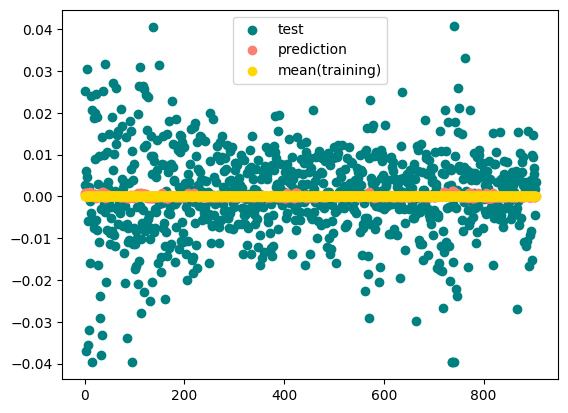

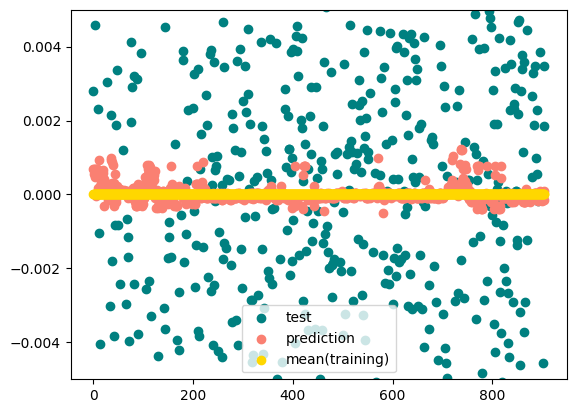

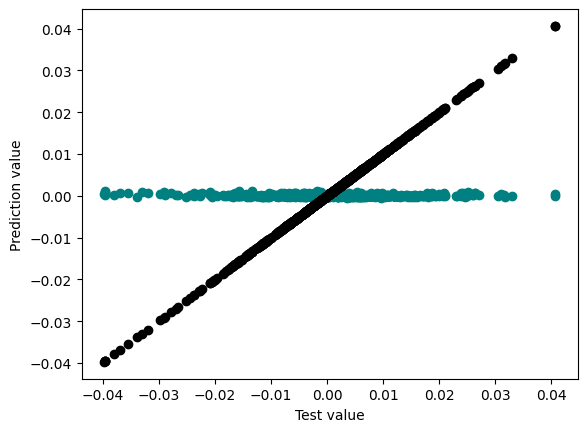

In [33]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
naive_pred = np.full_like(y_test, fill_value=y_train.mean())


n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_HGB), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')

plt.legend()
plt.show()
#============ plot with zoom =============0
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter(n_pred, y_test, label = 'test', color = 'teal')
ax.scatter(n_pred, list(y_pred_HGB), label = 'prediction', color = 'salmon')
ax.scatter(n_pred, naive_pred, label = 'mean(training)', color = 'gold')
ax.set_ylim(-0.005,0.005)
plt.legend()
plt.show()
# ============= Plot prediciton vs true
fig, ax = plt.subplots()

n_pred = np.arange(len(list(y_test)))#number of prediction samples

ax.scatter( y_test, y_pred_HGB, color = 'teal')
ax.scatter( y_test, y_test, color = 'black')
ax.set_xlabel("Test value")
ax.set_ylabel("Prediction value")
plt.show()

**Observation** The addition of the new features barely has any effect on  the prediction ability.
Now, I will implement `pinball`regression. It means, instead of training the regressor to minimize the `squared error`, it will be trained to minimize a specific quantile of the data. This is because the model is predicting the average value of the target variable, which is what is expected of a gradient boosting regressor.

In [34]:
from dataclasses import asdict
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_pinball_loss, make_scorer


def train_quantile_models(
    X_train, y_train, X_test, y_test,
    quantiles: list[float],
    HGB_params,
    time_cv,
    n_iter: int = 30,
    random_state: int = 0,
) -> dict[float, dict]:
    """Trains one HistGradientBoostingRegressor per target quantile, each optimized via
    pinball loss (not MSE/R²), with hyperparameters tuned by RandomizedSearchCV scored on
    pinball loss AT THAT SAME quantile — so the search optimizes exactly what the model is
    trained to predict, rather than defaulting to the mean-prediction objective (R²) that
    doesn't match a quantile model's actual target.

    A separate model is required per quantile because HistGradientBoostingRegressor's
    `loss="quantile"` only supports a single scalar `quantile` parameter per fit — there is
    no native multi-quantile output in one model.

    Args:
        X_train, y_train: training features/target.
        X_test, y_test: held-out test features/target, used only for final reporting
            (not used in the hyperparameter search itself, which uses `time_cv` on train).
        quantiles: list of target quantiles to fit, e.g. [0.1, 0.5, 0.9].
        HGB_params: a dataclass/object of param distributions (as passed to
            RandomizedSearchCV's `param_distributions`, same shape as your existing
            HGB_params) — reused identically for every quantile's search.
        time_cv: a pre-built TimeSeriesSplit (or similar) cross-validator, to avoid
            leakage from a time-series dataset.
        n_iter: number of RandomizedSearchCV iterations per quantile.
        random_state: seed, applied to both the model and the search for reproducibility.

    Returns:
        dict keyed by quantile, each value a dict with:
        - 'model': the best fitted HistGradientBoostingRegressor for that quantile.
        - 'best_params': the winning hyperparameter combination.
        - 'cv_pinball_loss': best cross-validated pinball loss (lower is better).
        - 'test_pinball_loss': pinball loss evaluated on X_test/y_test.
        - 'test_predictions': the model's predictions on X_test (cached here so a
          separate plotting step doesn't need to re-predict).
    """
    results = {}
    for q in quantiles:
        hgb_q = HistGradientBoostingRegressor(
            loss="quantile", quantile=q, early_stopping=True, random_state=random_state,
        )
        pinball_scorer = make_scorer(mean_pinball_loss, alpha=q, greater_is_better=False)

        search = RandomizedSearchCV(
            hgb_q,
            param_distributions=asdict(HGB_params),
            n_iter=n_iter,
            cv=time_cv,
            scoring=pinball_scorer,
            random_state=random_state,
            n_jobs=-1,
        )
        search.fit(X_train, y_train)

        test_preds = search.best_estimator_.predict(X_test)
        test_loss = mean_pinball_loss(y_test, test_preds, alpha=q)

        print(f"[q={q}] best params: {search.best_params_}")
        print(f"[q={q}] CV pinball loss: {-search.best_score_:.6f} | test pinball loss: {test_loss:.6f}")

        results[q] = {
            "model": search.best_estimator_,
            "best_params": search.best_params_,
            "cv_pinball_loss": -search.best_score_,
            "test_pinball_loss": test_loss,
            "test_predictions": test_preds,
        }
    return results

In [35]:
QUANTILES= [0.1,0.5,0.9]

In [36]:
results = train_quantile_models(X_train, y_train, X_test, y_test, QUANTILES, HGB_params, time_cv)

[q=0.1] best params: {'learning_rate': np.float64(0.2890346780840571), 'max_depth': 3, 'max_iter': np.int64(100), 'max_leaf_nodes': 34, 'min_samples_leaf': 105}
[q=0.1] CV pinball loss: 0.002067 | test pinball loss: 0.001859
[q=0.5] best params: {'learning_rate': np.float64(0.03060045687738721), 'max_depth': 4, 'max_iter': np.int64(100), 'max_leaf_nodes': 31, 'min_samples_leaf': 89}
[q=0.5] CV pinball loss: 0.003869 | test pinball loss: 0.003839
[q=0.9] best params: {'learning_rate': np.float64(0.2839539859443793), 'max_depth': 5, 'max_iter': np.int64(100), 'max_leaf_nodes': 38, 'min_samples_leaf': 173}
[q=0.9] CV pinball loss: 0.001810 | test pinball loss: 0.001924


In [37]:
for q, model in results.items():
    preds = model["model"].predict(X_test)
    empirical_coverage = (y_test.to_numpy()  <= preds).mean()
    print(f"q={q}: nominal={q:.2f}, empirical coverage={empirical_coverage:.3f}")

q=0.1: nominal=0.10, empirical coverage=0.093
q=0.5: nominal=0.50, empirical coverage=0.464
q=0.9: nominal=0.90, empirical coverage=0.813


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# validated palette slots, reused from earlier charts for consistency
COLOR_TRUE, COLOR_PRED, COLOR_NAIVE, COLOR_DIAG = "#2a78d6", "#eb6834", "#eda100", "#898781"
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"


def plot_quantile_diagnostics(
    y_train, y_test, quantile_results: dict[float, dict], 
    zoom_ylim: tuple[float, float] | None = None,
) -> None:
    """Builds a diagnostic grid with one COLUMN per quantile model and three ROWS of
    plots per model, so every quantile model gets its own dedicated set of subplots
    rather than overwriting a single shared 'preds' variable (the issue in the original
    code, which only ever showed one model's output regardless of how many were trained).

    Row 1 — predictions and actuals plotted against row index, full y-range: shows
      whether a quantile's predictions track the test target's shape over time.
    Row 2 — same as row 1, zoomed to `zoom_ylim` if given: the full range is often
      dominated by a few large test values, making small differences invisible — this
      row answers "how do predictions behave in the 'ordinary' range" the way your
      original zoomed plot did.
    Row 3 — predicted vs. actual scatter, with the y=x reference line: the standard
      calibration check. Points hugging the diagonal mean good agreement; a cloud of
      points consistently above or below the line means the quantile model is
      systematically over- or under-shooting at that quantile.

    Args:
        y_train: training target (only its mean is used, as the naive baseline).
        y_test: held-out test target.
        quantile_results: output of train_quantile_models() — dict keyed by quantile,
            each value containing at least 'test_predictions'.
        zoom_ylim: (ymin, ymax) for row 2's y-axis. If None, row 2 is skipped.
    """
    quantiles = sorted(quantile_results.keys())
    n_cols = len(quantiles)
    n_rows = 4 if zoom_ylim is not None else 3
    n_pred = np.arange(len(y_test))
    naive_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    fig.patch.set_facecolor(SURFACE)
    q_values = {q: np.quantile(y_train, q) for q in QUANTILES}
    for col, q in enumerate(quantiles):
        q_val = q_values[q]
        base = np.full(len(y_test), q_val)# array of len(y_test) filled with the 
            #mean of the training quantile, if the prediction is done by using the mean of the 
            #training data
        preds = quantile_results[q]["test_predictions"]

        # Row 1: full-range scatter over index
        ax = axes[0][col]
        ax.set_facecolor(SURFACE)
        ax.scatter(n_pred, y_test, label="test", color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
        ax.scatter(n_pred, preds, label="prediction", color=COLOR_PRED, s=12, alpha=0.7, zorder=3)
        ax.scatter(n_pred, naive_pred, label="mean(train)", color=COLOR_NAIVE, s=8, alpha=0.7, zorder=2)
        ax.scatter(n_pred, base, label="Quantile mean(train)", color="teal", s=8, zorder=2)
        ax.set_title(f"q={q}", color=INK_PRIMARY, fontsize=11)
        if col == 0:
            ax.set_ylabel("target (full range)", color=INK_SECONDARY)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
        for s in ["top", "right"]: ax.spines[s].set_visible(False)

        row_idx = 1
        if zoom_ylim is not None:
            # Row 2: zoomed scatter over index
            ax = axes[row_idx][col]
            ax.set_facecolor(SURFACE)
            ax.scatter(n_pred, y_test, color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
            ax.scatter(n_pred, preds, color=COLOR_PRED, s=12, alpha=0.7, zorder=3)
            ax.scatter(n_pred, naive_pred, color=COLOR_NAIVE, s=8, alpha=0.7, zorder=2)
            ax.set_ylim(*zoom_ylim)
            if col == 0:
                ax.set_ylabel("target (zoomed)", color=INK_SECONDARY)
            ax.tick_params(colors=INK_MUTED, labelsize=8)
            ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
            for s in ["top", "right"]: ax.spines[s].set_visible(False)
            row_idx += 1

        # Last row: predicted vs actual (calibration)
        ax = axes[row_idx][col]
        ax.set_facecolor(SURFACE)
        ax.scatter(y_test, preds, color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
        lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
        ax.plot(lims, lims, color=COLOR_DIAG, linewidth=1.2, zorder=2)  # y = x reference
        ax.set_xlabel("test value", color=INK_SECONDARY)
        if col == 0:
            ax.set_ylabel("prediction", color=INK_SECONDARY)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
        for s in ["top", "right"]: ax.spines[s].set_visible(False)

        # ====== Plotting y_test but only for the quantile values of each quantile prediction =====
        row_idx += 1
        ax = axes[row_idx][col]
        ax.set_facecolor(SURFACE)
        #=========================================================================
        # Define the mask based on what portion of the data the quantile represents
        if q == 0.1:
            mask = y_test <= q_val                  # Bottom 10%
        elif q == 0.9:
            mask = y_test >= q_val                  # Top 10%
        else:
            # Middle band between 0.1 and 0.9 quantiles
            mask = (y_test > q_values[0.1]) & (y_test < q_values[0.9])
        #=========================================================================
        y_q_test = y_test.filter(mask)
        preds_q = preds[mask]
        
        ax.scatter(y_q_test, preds_q, color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
        lims = [min(y_q_test.min(), preds_q.min()), max(y_q_test.max(), preds_q.max())]
        ax.plot(lims, lims, color=COLOR_DIAG, linewidth=1.2, zorder=2)  # y = x reference
        ax.set_xlabel("test value (cropped to quantile)", color=INK_SECONDARY)
        if col == 0:
            ax.set_ylabel("prediction", color=INK_SECONDARY)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
        for s in ["top", "right"]: ax.spines[s].set_visible(False)
    

    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
               labelcolor=INK_SECONDARY, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Quantile model diagnostics", color=INK_PRIMARY, fontsize=14)
    plt.tight_layout()
    plt.show()

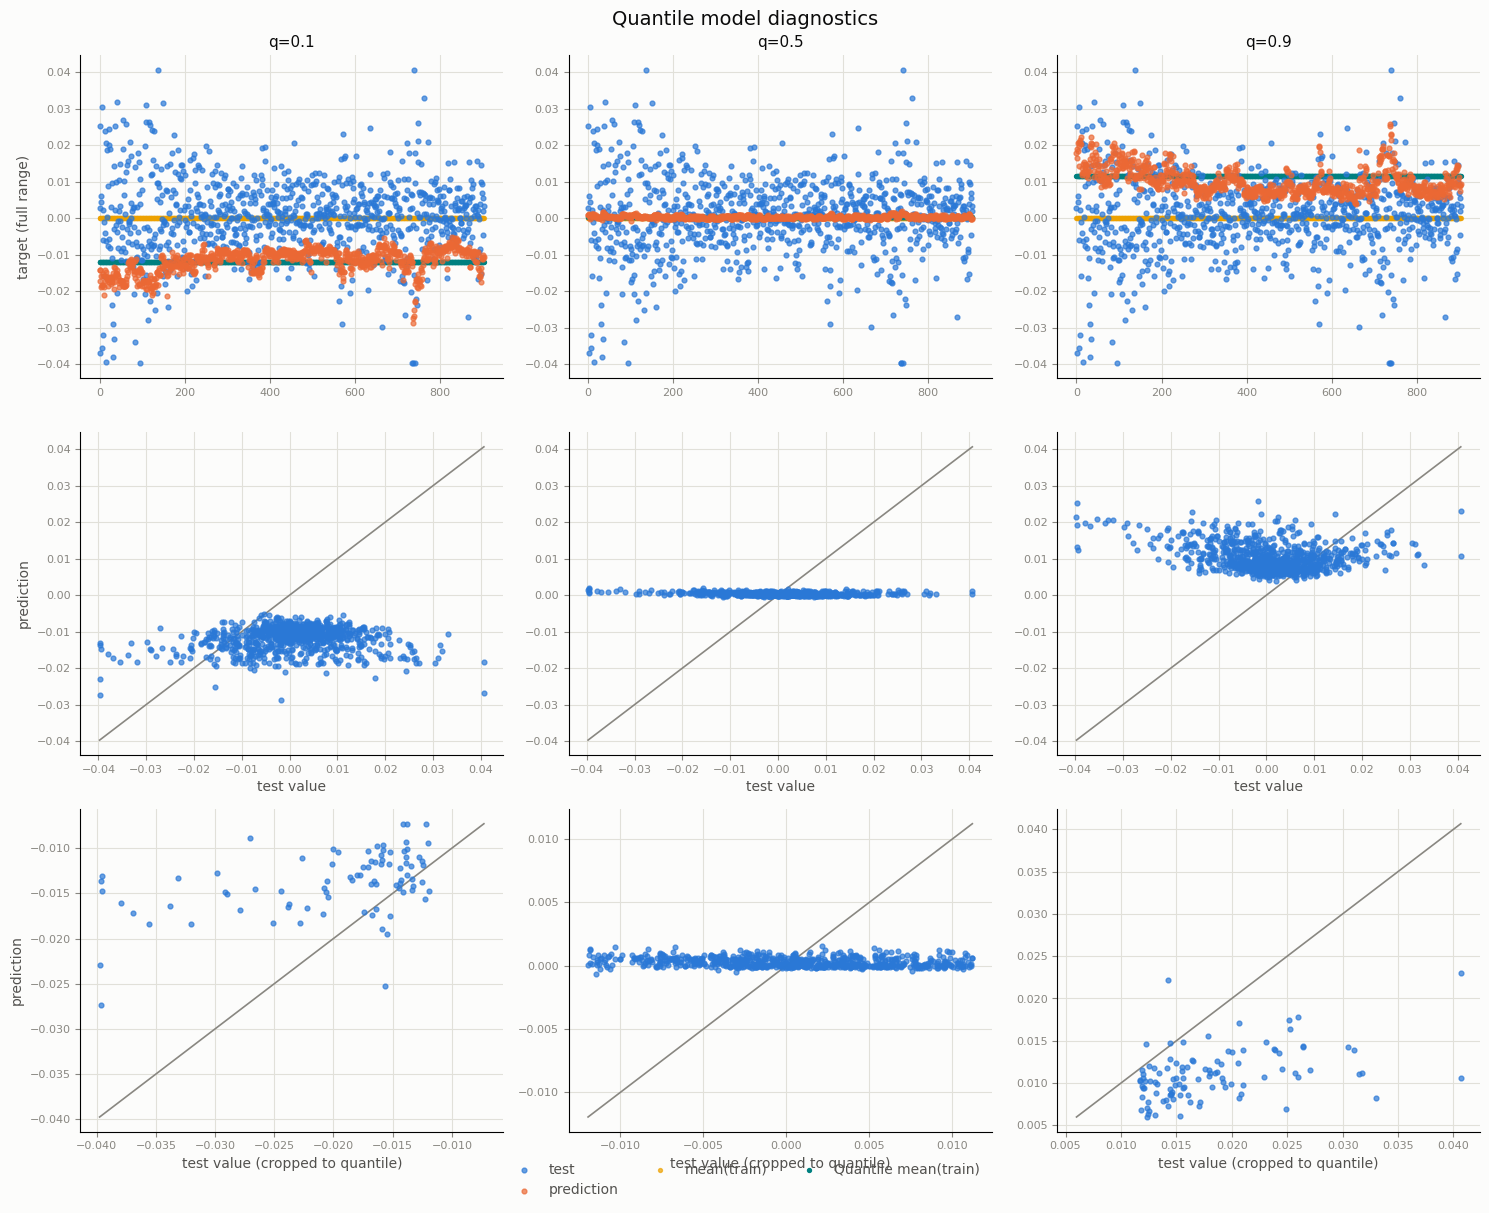

In [39]:
plot_quantile_diagnostics(y_train, y_test, results, zoom_ylim=None)

## Checking prediction power on the CV vs. test data.
This allows me to see if the model is predicting too well with the training data but poorly on the test data (overfitting) or if predictions on both datasets are poor (underfitting)

In [63]:
# validated palette slots, reused from earlier charts for consistency
COLOR_TRUE, COLOR_PRED, COLOR_NAIVE, COLOR_DIAG = "#2a78d6", "#eb6834", "#eda100", "#898781"
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

In [64]:
def cv_vs_test_skill(
    results: dict[float, dict],
    X_train, y_train, X_test, y_test,
    quantiles: list[float],
    time_cv,
    random_state: int = 0,
    plot: bool = True,
) -> tuple[pl.DataFrame, dict[float, np.ndarray]]:
    """Compares each quantile model's skill under time-series cross-validation (CV) with
    its skill on the untouched test set, to separate "the features carry no signal" from
    "the model overfits or the relationship shifted between train and test".

    GOAL OF THE COMPARISON
        CV skill > 0 and test skill ~ 0 (or negative): signal exists in-sample but does not
        carry forward -> overfitting or non-stationarity (regime shift), not just weak features.
        CV skill ~ 0 and test skill ~ 0: no usable signal for that quantile.
        Both clearly > 0 (and similar): stable, usable signal.
        `skill_gap` = cv_skill - test_skill summarizes this; a large positive gap is the warning sign.

    METRICS (computed per quantile, for both CV and test)
        - pinball_loss: the loss each quantile model is trained to minimize,
              L_q(y, p) = mean( max(q*(y-p), (q-1)*(y-p)) ).
          It is the only metric that is proper for a q-quantile forecast. Lower is better.
        - baseline_pinball_loss: the same loss for a constant forecast equal to the
          unconditional q-quantile of the TRAINING target (per CV fold: of that fold's
          training part, so the baseline never sees the rows it is scored on).
        - skill = 1 - pinball_loss / baseline_pinball_loss. Interpretation: > 0 beats a
          constant, 0 equals it, < 0 is worse than predicting a constant. This is the main
          number to judge a quantile model by.
        - r2: sklearn's R^2 between the model's prediction and the true target. Reported for
          comparability with the earlier mean-based models. Caution: it is only meaningful
          near q=0.5; for q=0.1 or 0.9 the prediction is deliberately offset from the
          mean, so R^2 is expected to be low or negative even for a perfect quantile model.
          Also, sklearn uses the evaluated set's own mean as the reference, which is slightly
          generous on test.

    CV PREDICTIONS ARE OUT-OF-FOLD
        For each `time_cv` fold, the quantile model (with the tuned `best_params`) is refit on
        the fold's training part and predicts the fold's validation part, so every CV
        prediction comes from a model that never saw that row. Rows that are never in a
        validation fold (the earliest block in TimeSeriesSplit) have no CV prediction and are
        excluded. In-sample predictions of the final model are deliberately NOT used: they
        look excellent and say nothing about generalization.

    Args:
        results: output of train_quantile_models; needs results[q]['model'] and
            results[q]['best_params'] for every q in `quantiles`.
        X_train, y_train: training features / target (used for CV and for the baselines).
        X_test, y_test: untouched held-out features / target.
        quantiles: quantiles to evaluate, e.g. [0.1, 0.5, 0.9].
        time_cv: the same time-series cross-validator used for tuning (e.g. TimeSeriesSplit).
        random_state: seed for the per-fold refits.
        plot: if True, draws the diagnostic figure (see below).

    Returns:
        summary: polars DataFrame, one row per quantile, with columns
            quantile, cv_r2, cv_pinball, cv_baseline_pinball, cv_skill,
            test_r2, test_pinball, test_baseline_pinball, test_skill, skill_gap.
        oof_preds: dict {quantile: array of length len(y_train)} of out-of-fold predictions,
            NaN where a row has no CV prediction. Reusable for further analysis or plots.

    Figure (if plot=True)
        Row 1: out-of-fold predictions vs. true target on the training data, one panel per quantile.
        Row 2: predictions vs. true target on the test data, one panel per quantile
               (y-axis shared with row 1 for direct comparison).
        Row 3: histogram of the training target, with the unconditional quantiles marked.
        Dashed line in rows 1-2: the constant baseline (unconditional train quantile).
    """
    X_train_arr, X_test_arr = np.asarray(X_train), np.asarray(X_test)
    y_train_arr, y_test_arr = np.asarray(y_train), np.asarray(y_test)
    n_train = len(y_train_arr)

    rows, oof_preds, test_preds_all, test_baselines = [], {}, {}, {}

    for q in quantiles:
        best_params = results[q]["best_params"]

        # --- out-of-fold CV predictions + per-fold constant baseline ---
        oof = np.full(n_train, np.nan)
        base_cv = np.full(n_train, np.nan)
        for tr_idx, va_idx in time_cv.split(X_train_arr):
            fold_model = HistGradientBoostingRegressor(
                loss="quantile", quantile=q, early_stopping=True,
                random_state=random_state, **best_params,
            )
            fold_model.fit(X_train_arr[tr_idx], y_train_arr[tr_idx])
            oof[va_idx] = fold_model.predict(X_train_arr[va_idx])
            base_cv[va_idx] = np.quantile(y_train_arr[tr_idx], q)
        oof_preds[q] = oof
        valid = ~np.isnan(oof)

        cv_pin = mean_pinball_loss(y_train_arr[valid], oof[valid], alpha=q)
        cv_base = mean_pinball_loss(y_train_arr[valid], base_cv[valid], alpha=q)

        # --- test: final (full-train) model vs. constant train-quantile baseline ---
        test_pred = results[q]["model"].predict(X_test_arr)
        test_base_value = np.quantile(y_train_arr, q)
        test_pin = mean_pinball_loss(y_test_arr, test_pred, alpha=q)
        test_base = mean_pinball_loss(y_test_arr, np.full(len(y_test_arr), test_base_value), alpha=q)
        test_preds_all[q], test_baselines[q] = test_pred, test_base_value

        cv_skill, test_skill = 1 - cv_pin / cv_base, 1 - test_pin / test_base
        rows.append({
            "quantile": q,
            "cv_r2": r2_score(y_train_arr[valid], oof[valid]),
            "cv_pinball": cv_pin, "cv_baseline_pinball": cv_base, "cv_skill": cv_skill,
            "test_r2": r2_score(y_test_arr, test_pred),
            "test_pinball": test_pin, "test_baseline_pinball": test_base, "test_skill": test_skill,
            "skill_gap": cv_skill - test_skill,
        })

    summary = pl.DataFrame(rows)
    with pl.Config(tbl_rows=len(quantiles), float_precision=4):
        print(summary)

    if plot:
        _plot_cv_vs_test(y_train_arr, y_test_arr, quantiles, oof_preds, test_preds_all,
                         test_baselines, summary)
    return summary, oof_preds


def _plot_cv_vs_test(y_train, y_test, quantiles, oof_preds, test_preds, baselines, summary):
    """Figure for cv_vs_test_skill: OOF train panels, test panels, train-target histogram."""
    n_cols = len(quantiles)
    fig = plt.figure(figsize=(5 * n_cols, 12))
    fig.patch.set_facecolor(SURFACE)
    gs = fig.add_gridspec(3, n_cols, height_ratios=[1, 1, 0.8])

    def style(ax):
        ax.set_facecolor(SURFACE)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
        for s in ["top", "right"]: ax.spines[s].set_visible(False)

    first_ax = None
    for col, q in enumerate(quantiles):
        skill_row = summary.filter(pl.col("quantile") == q).row(0, named=True)

        # Row 1: out-of-fold predictions on training data
        ax = fig.add_subplot(gs[0, col], sharey=first_ax)
        first_ax = first_ax or ax
        valid = ~np.isnan(oof_preds[q])
        x = np.where(valid)[0]
        ax.scatter(x, y_train[valid], color=COLOR_TRUE, s=8, alpha=0.6, zorder=3, label="true")
        ax.scatter(x, oof_preds[q][valid], color=COLOR_PRED, s=8, alpha=0.6, zorder=3,
                   label="out-of-fold prediction")
        ax.axhline(baselines[q], color=COLOR_NAIVE, linestyle="--", linewidth=1.2, zorder=2,
                   label="constant baseline")
        ax.set_title(f"q={q} | train (CV) skill {skill_row['cv_skill']:+.3f}",
                     color=INK_PRIMARY, fontsize=11)
        if col == 0:
            ax.set_ylabel("target", color=INK_SECONDARY)
        style(ax)

        # Row 2: predictions on test data (y shared with row 1)
        ax = fig.add_subplot(gs[1, col], sharey=first_ax)
        xt = np.arange(len(y_test))
        ax.scatter(xt, y_test, color=COLOR_TRUE, s=8, alpha=0.6, zorder=3)
        ax.scatter(xt, test_preds[q], color=COLOR_PRED, s=8, alpha=0.6, zorder=3)
        ax.axhline(baselines[q], color=COLOR_NAIVE, linestyle="--", linewidth=1.2, zorder=2)
        ax.set_title(f"q={q} | test skill {skill_row['test_skill']:+.3f}",
                     color=INK_PRIMARY, fontsize=11)
        ax.set_xlabel("row index", color=INK_SECONDARY)
        if col == 0:
            ax.set_ylabel("target", color=INK_SECONDARY)
        style(ax)

    # Row 3: histogram of the training target with unconditional quantiles
    ax = fig.add_subplot(gs[2, :])
    ax.hist(y_train, bins=60, color=COLOR_TRUE, alpha=0.75, zorder=3)
    ymax = ax.get_ylim()[1]
    for q in quantiles:
        v = np.quantile(y_train, q)
        ax.axvline(v, color=COLOR_PRED, linestyle="--", linewidth=1.2, zorder=4)
        ax.text(v, ymax * 0.97, f" q={q}", color=INK_SECONDARY, fontsize=8, va="top")
    ax.set_xlabel("training target value", color=INK_SECONDARY)
    ax.set_ylabel("count", color=INK_SECONDARY)
    ax.set_title("Distribution of the training target", color=INK_PRIMARY, fontsize=11)
    style(ax)

    handles, labels = fig.axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
               labelcolor=INK_SECONDARY, bbox_to_anchor=(0.5, -0.01))
    fig.suptitle("Quantile models: CV vs. test", color=INK_PRIMARY, fontsize=14)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


shape: (3, 10)
┌──────────┬─────────┬────────────┬────────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ quantile ┆ cv_r2   ┆ cv_pinball ┆ cv_baselin ┆ … ┆ test_pinb ┆ test_base ┆ test_skil ┆ skill_gap │
│ ---      ┆ ---     ┆ ---        ┆ e_pinball  ┆   ┆ all       ┆ line_pinb ┆ l         ┆ ---       │
│ f64      ┆ f64     ┆ f64        ┆ ---        ┆   ┆ ---       ┆ all       ┆ ---       ┆ f64       │
│          ┆         ┆            ┆ f64        ┆   ┆ f64       ┆ ---       ┆ f64       ┆           │
│          ┆         ┆            ┆            ┆   ┆           ┆ f64       ┆           ┆           │
╞══════════╪═════════╪════════════╪════════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0.1000   ┆ -1.1332 ┆ 0.0021     ┆ 0.0021     ┆ … ┆ 0.0019    ┆ 0.0020    ┆ 0.0771    ┆ -0.0410   │
│ 0.5000   ┆ -0.0016 ┆ 0.0039     ┆ 0.0039     ┆ … ┆ 0.0038    ┆ 0.0038    ┆ -0.0111   ┆ 0.0112    │
│ 0.9000   ┆ -1.1876 ┆ 0.0018     ┆ 0.0020     ┆ … ┆ 0.0019    ┆ 0.0018    ┆

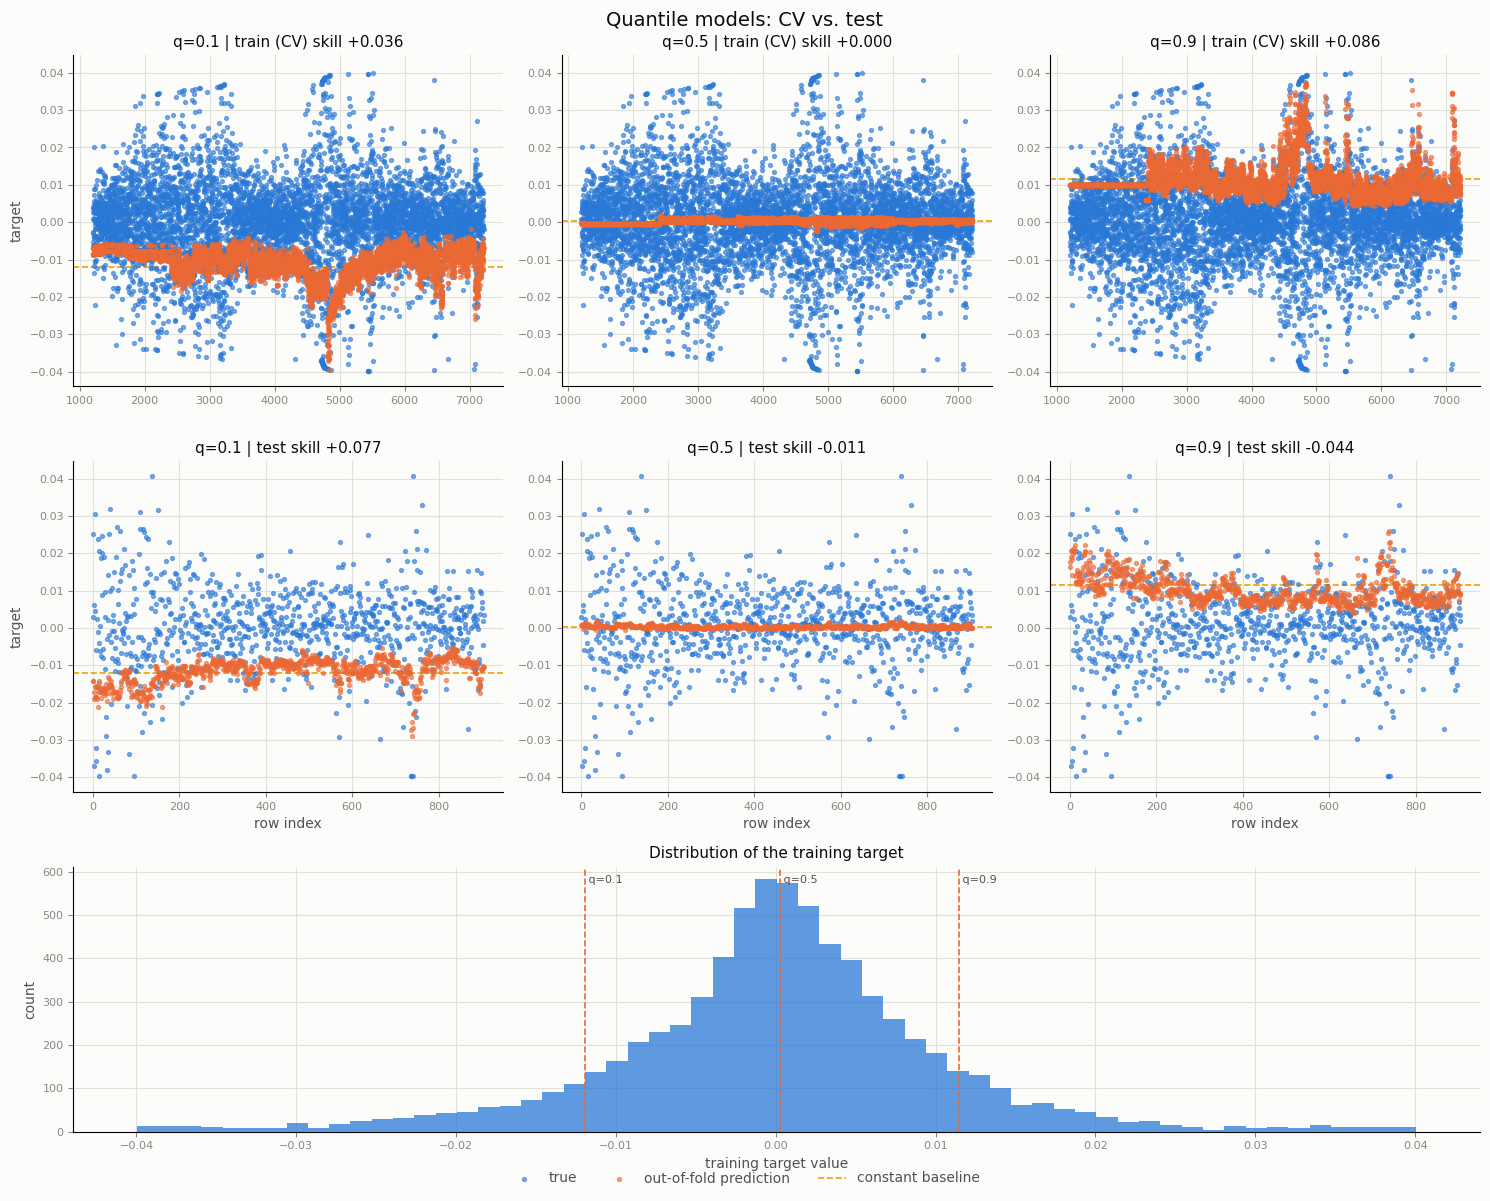

In [65]:
summary, oof_preds = cv_vs_test_skill(
    results, X_train, y_train, X_test, y_test,
    quantiles=[0.1, 0.5, 0.9], time_cv=time_cv,
)

### This shows me that the model is probably overfitting for the quantile=0.9, while it generalizes for the other quantiles. Additionally, we can see that most of our target has data around zero with a significant lower amount of data for the larger values. This is highly realted to the fact that the model has learned to predict the mean as by doing so, the loss is reduced.

## Prediction with the quatile=0.5 and using the other quantiles as dispersion

In [40]:
import numpy as np


def _conformal_correction(lo_raw, hi_raw, y_true, alpha, cluster_labels=None):
    """Computes the CQR correction Q_hat, globally and per-regime if cluster_labels is
    given. The global value is always included, as a fallback for any regime that didn't
    appear in the calibration slice."""
    E = np.maximum(lo_raw - y_true, y_true - hi_raw)
    n = len(y_true)
    level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    Q_hat = {"_global": np.quantile(E, level)}

    if cluster_labels is None:
        return Q_hat

    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        n_c = mask.sum()
        if n_c < 10:  # too few calibration points for a reliable per-cluster quantile
            continue
        level_c = min(np.ceil((n_c + 1) * (1 - alpha)) / n_c, 1.0)
        Q_hat[c] = np.quantile(E[mask], level_c)
    return Q_hat

def predict_with_quantile_models(
    results: dict[float, dict],
    X_test, y_test,
    cluster_labels_test=None,
    quantile_lo: float = 0.1,
    quantile_hi: float = 0.9,
    quantile_point: float = 0.5,
    calib_frac: float = 0.3,
):
    """
    Produces the final point estimate + conformalized interval directly from the quantile
    models in `results`, as discussed: f_0.5 as the point estimate, conformalized
    [f_0.1, f_0.9] as the interval, regime-stratified by cluster_labels_test if given.
    No super learner, no meta-model — just the base quantile models, used correctly.

    X_test/y_test is split CHRONOLOGICALLY (not randomly — this is time-series data) into:
        - calibration portion (first calib_frac): used ONLY to compute the conformal
          correction Q_hat (never scored/reported on).
        - evaluation portion (remainder, strictly later in time): where point estimate,
          interval, and true values are returned for you to plot/report.
    This keeps the reported predictions honest — none of the evaluation rows contribute
    to their own interval's calibration.

    Args:
        results: output of train_quantile_models — dict keyed by quantile, each with
            'model' (fitted estimator). Must contain quantile_lo, quantile_point, quantile_hi.
        X_test, y_test: held-out test features/target (never used in model TRAINING).
        cluster_labels_test: optional, same n_rows as X_test — regime label per row
            (e.g. from assign_clusters). If given, Q_hat is computed per regime
            (Mondrian conformal) instead of pooled, matching your validated finding that
            interval width should vary by volatility regime.
        quantile_lo, quantile_hi: the interval's quantile pair. Nominal coverage target is
            (quantile_hi - quantile_lo), e.g. 0.1/0.9 -> 80% nominal.
        quantile_point: which fitted model's output to use as the point estimate.
        calib_frac: fraction of X_test (by time order) used for conformal calibration.

    Returns:
        dict with:
        - 'y_eval': true target values on the evaluation portion.
        - 'point_pred': f_quantile_point predictions on the evaluation portion.
        - 'lower', 'upper': conformalized interval bounds on the evaluation portion.
        - 'idx_eval': original row indices (into X_test/y_test) of the evaluation portion,
          useful for aligning with y_train when plotting a full-range index scatter.
    """
    X_test_arr, y_test_arr = np.asarray(X_test), np.asarray(y_test)
    n = len(y_test_arr)
    n_calib = int(n * calib_frac)

    idx_calib = np.arange(0, n_calib)
    idx_eval = np.arange(n_calib, n)

    model_lo = results[quantile_lo]["model"]
    model_hi = results[quantile_hi]["model"]
    model_pt = results[quantile_point]["model"]

    # --- calibration portion: compute Q_hat only, never reported ---
    lo_calib = model_lo.predict(X_test_arr[idx_calib])
    hi_calib = model_hi.predict(X_test_arr[idx_calib])
    y_calib = y_test_arr[idx_calib]
    cluster_calib = cluster_labels_test[idx_calib] if cluster_labels_test is not None else None

    alpha = 1 - (quantile_hi - quantile_lo)
    Q_hat = _conformal_correction(lo_calib, hi_calib, y_calib, alpha, cluster_calib)

    # --- evaluation portion: the predictions you actually use/plot ---
    X_eval = X_test_arr[idx_eval]
    y_eval = y_test_arr[idx_eval]
    point_pred = model_pt.predict(X_eval)
    lo_raw = model_lo.predict(X_eval)
    hi_raw = model_hi.predict(X_eval)

    if cluster_labels_test is None:
        q_hat_eval = np.full(len(idx_eval), Q_hat["_global"])
    else:
        cluster_eval = cluster_labels_test[idx_eval]
        q_hat_eval = np.array([Q_hat.get(c, Q_hat["_global"]) for c in cluster_eval])

    lower = lo_raw - q_hat_eval
    upper = hi_raw + q_hat_eval

    # enforce point estimate stays within its own interval (guards rare crossing)
    lower = np.minimum(lower, point_pred)
    upper = np.maximum(upper, point_pred)

    return {
        "y_eval": y_eval,
        "point_pred": point_pred,
        "lower": lower,
        "upper": upper,
        "idx_eval": idx_eval,
    }

In [41]:
cluster_labels_test = ds_test_KMeans_out["cluster_label"].to_numpy()  # or however you access that column

pred = predict_with_quantile_models(results, X_test, y_test, cluster_labels_test=cluster_labels_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with featur

In [42]:
import numpy as np
import matplotlib.pyplot as plt

COLOR_TRUE, COLOR_PRED, COLOR_DIAG = "#2a78d6", "#eb6834", "#898781"
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"


def plot_quantile_interval_diagnostics(pred: dict, zoom_ylim: tuple[float, float] | None = None) -> None:
    """Plots the direct quantile-model prediction (median point estimate + conformalized
    interval) against the true test values, matching the style of the earlier diagnostic
    plots.

    Row 1 — full-range index scatter: y_eval (true) vs point_pred, with the conformalized
      [lower, upper] interval shaded behind them.
    Row 2 — same, zoomed to `zoom_ylim` if given.
    Row 3 — predicted vs. actual calibration scatter, with vertical error bars showing each
      point's interval width, and the y=x reference line.

    Args:
        pred: the dict returned by predict_with_quantile_models — needs 'y_eval',
            'point_pred', 'lower', 'upper'.
        zoom_ylim: (ymin, ymax) for row 2's y-axis. If None, row 2 is skipped.
    """
    y_eval, point_pred = pred["y_eval"], pred["point_pred"]
    lower, upper = pred["lower"], pred["upper"]
    idx = np.arange(len(y_eval))

    n_rows = 3 if zoom_ylim is not None else 2
    fig, axes = plt.subplots(n_rows, 1, figsize=(10, 4 * n_rows))
    fig.patch.set_facecolor(SURFACE)

    def _style(ax):
        ax.set_facecolor(SURFACE)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        ax.grid(True, color=GRID, linewidth=0.8, zorder=0); ax.set_axisbelow(True)
        for s in ["top", "right"]: ax.spines[s].set_visible(False)

    # Row 1: full-range index scatter + interval band
    ax = axes[0]
    ax.fill_between(idx, lower, upper, color=COLOR_PRED, alpha=0.15, zorder=1, label="conformal interval")
    ax.scatter(idx, y_eval, label="y_test (true)", color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
    ax.scatter(idx, point_pred, label="point pred (q=0.5)", color=COLOR_PRED, s=12, alpha=0.7, zorder=3)
    ax.set_title("Quantile-model prediction — full range", color=INK_PRIMARY, fontsize=11)
    ax.set_ylabel("target", color=INK_SECONDARY)
    _style(ax)

    row_idx = 1
    if zoom_ylim is not None:
        ax = axes[row_idx]
        ax.fill_between(idx, lower, upper, color=COLOR_PRED, alpha=0.15, zorder=1)
        ax.scatter(idx, y_eval, color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
        ax.scatter(idx, point_pred, color=COLOR_PRED, s=12, alpha=0.7, zorder=3)
        ax.set_ylim(*zoom_ylim)
        ax.set_title("Zoomed", color=INK_PRIMARY, fontsize=11)
        ax.set_ylabel("target (zoomed)", color=INK_SECONDARY)
        _style(ax)
        row_idx += 1

    # Last row: predicted vs actual, with interval shown as error bars
    ax = axes[row_idx]
    yerr = np.vstack([point_pred - lower, upper - point_pred])
    ax.errorbar(y_eval, point_pred, yerr=yerr, fmt="none", ecolor=COLOR_PRED, alpha=0.25, zorder=2)
    ax.scatter(y_eval, point_pred, color=COLOR_TRUE, s=12, alpha=0.7, zorder=3)
    lims = [min(y_eval.min(), lower.min()), max(y_eval.max(), upper.max())]
    ax.plot(lims, lims, color=COLOR_DIAG, linewidth=1.2, zorder=2, label="y = x")
    ax.set_xlabel("y_test (true)", color=INK_SECONDARY)
    ax.set_ylabel("point prediction", color=INK_SECONDARY)
    ax.set_title("Calibration (error bars = conformal interval)", color=INK_PRIMARY, fontsize=11)
    _style(ax)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
               labelcolor=INK_SECONDARY, bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Direct quantile-model prediction diagnostics", color=INK_PRIMARY, fontsize=14)
    plt.tight_layout()
    plt.show()

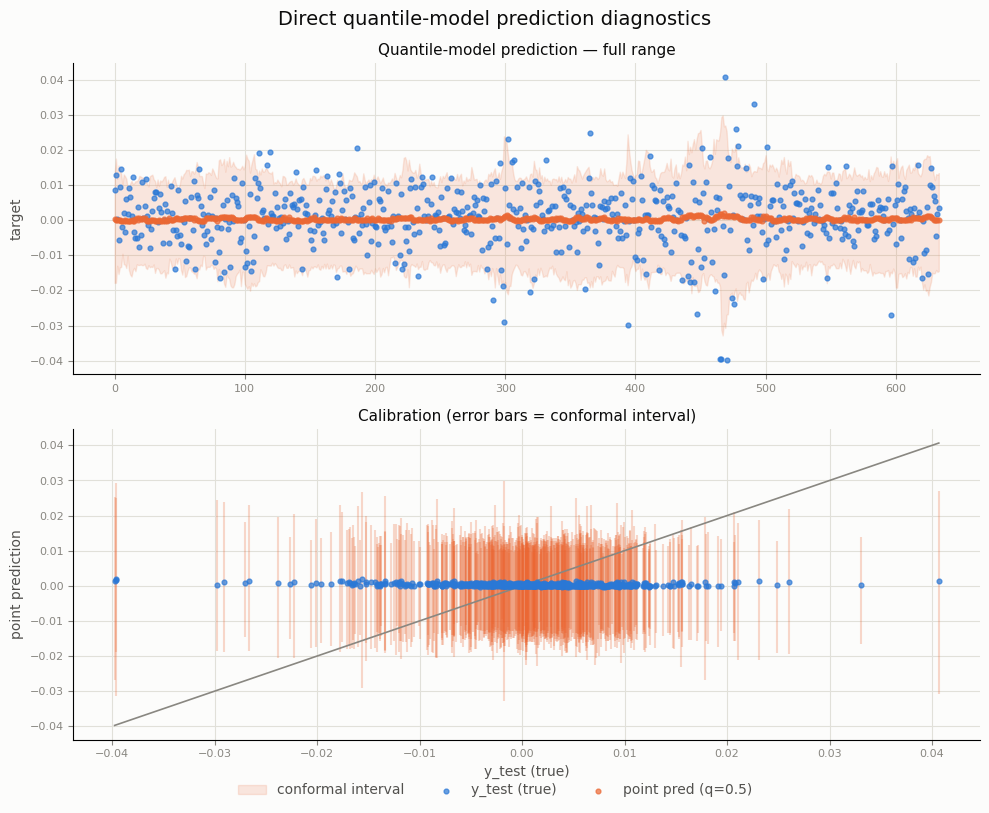

In [43]:
plot_quantile_interval_diagnostics(pred)

### The above Figure is showing the Q1, Q5,Q9, predictions of my model. The predicted value (Q5) is still predicting values close to the mean and it is not able to  predict the larger peaks ans valleys. On the other hand, Q1 and Q5, are able to predcit the valleys and peaks, respectively, but not values close to the mean

## Testing if each quantile model beat the mean of its own quantile

The following code computes predictions using each quantile model and compares these predictions with the quantile mean (for example, quantile=0.1, all data below 10% of the maximum, and compute the mean over this data). If the comparison shows that the prediction is able to be above the loss associated to simply predict the mean (skill=1; skill = 1-(model_loss/baseline_loss), this is a inidicate that more useful information for prediction is in the spread of the data (different data regimes)

In [48]:
def pinball_skill(results, y_train, y_test, quantiles):
    '''
    skill = 1 - (model_loss/baseline_loss); where baseline_loss = loss optained from computen the 
    mean and using it as prediction.
    If skill > 0: model performs better than simply predicting the mean of each quantile
       skill = 0: prediction at that quantile is insignificant, features carry no information for prediction
       
    '''
    result_q = {}
    for q in quantiles:
        #compute mean for each quantile
        base = np.full(len(y_test), np.quantile(y_train,q))# array of len(y_test) filled with the 
                        #quantile mean of the y_train
        skill = 1 - (results[q]["test_pinball_loss"]/mean_pinball_loss(y_test,base,alpha=q))
        result_q[q] = skill
    return(result_q)

In [49]:
result_q_sensitivity = pinball_skill(results,y_train,y_test, QUANTILES)

In [54]:
pldf_results_q = pl.DataFrame({
    "Quantile": list(result_q_sensitivity.keys()),
    "Values": list(result_q_sensitivity.values()),
})

In [62]:
from IPython.display import Markdown, display

# 1. Introduction text
display(
    Markdown("The skill of each quantile model is presented in the table below:")
)

# 2. Render the Polars table
display(pldf_results_q)

# 3. Conclusion and analysis text
display(
    Markdown(
        "The table shows that for `Model_q=0.5` and `Model_q=0.9`, the"
        " prediction is worse than if we were using the mean of the training"
        " data to predict every next value. However, `Model_q=0.1` shows an"
        " improvement with respect to the mean naive prediction.\n\nWith this,"
        " we can conclude that the added features to the model improved"
        " slightly the prediction ability, but these features still possess"
        " lower prediction power over our target."
    )
)

The skill of each quantile model is presented in the table below:

Quantile,Values
f64,f64
0.1,0.077107
0.5,-0.011093
0.9,-0.043981


The table shows that for `Model_q=0.5` and `Model_q=0.9`, the prediction is worse than if we were using the mean of the training data to predict every next value. However, `Model_q=0.1` shows an improvement with respect to the mean naive prediction.

With this, we can conclude that the added features to the model improved slightly the prediction ability, but these features still possess lower prediction power over our target.

# Summary

So far, my models only predict the mean. If I switch to the pinball loss, the model predicts a value below or above the mean, depending on the quantile. These predictions are bounds, not forecasts of the actual value. If the true value is larger than the mean and I use the q=0.1 model, it will still predict a value below the mean. The same happens in the opposite direction with the q=0.9 model. Therefore, I cannot use either model alone.

Most of my data is close to the mean (0), and only a few samples have large positive or negative values. I want a model that does not only predict the mean, but can also anticipate these large moves.

My first approach was to drop features with low relevance and low correlation with the target. Then I created clusters to define different regimes and added them as features. This gave almost no improvement, and the model still predicted the mean.

Several models agree on this result, so a more complex model is unlikely to help. I see two possible paths. First, I can change the loss function, so the model is not trained only to predict the mean. Second, I can keep doing feature engineering to create features that better describe large positive and negative returns, even though these samples are much rarer than the samples close to 0.

Before choosing, I need to decide what I want to predict: the direction of the return or the size of the move. The features may carry information about size only. 